In [1]:
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn import datasets
import matplotlib.pyplot as plt
sns.set()

# Dataset demo

In [41]:
df = pd.DataFrame({
    'col1': [5, 9, 13, 22, 31, 90, 81, 70, 45, 73, 85],
    'col2': [2, 8, 11, 10, 25, 80, 90, 80, 60, 62, 90]
})
df

,col1,col2
0,5,2
1,9,8
2,13,11
3,22,10
4,31,25
5,90,80
6,81,90
7,70,80
8,45,60
9,73,62


In [42]:
arr = np.array(df)
arr

array([[ 5,  2],
       [ 9,  8],
       [13, 11],
       [22, 10],
       [31, 25],
       [90, 80],
       [81, 90],
       [70, 80],
       [45, 60],
       [73, 62],
       [85, 90]], dtype=int64)

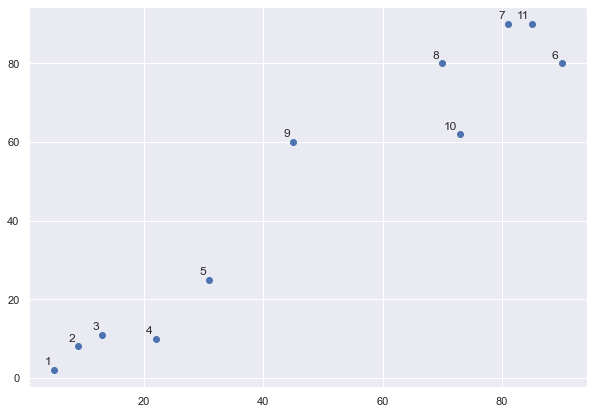

In [43]:
labels = range(1,12)
plt.figure(figsize=(10, 7))
plt.scatter(arr[:,0], arr[:,1])

for label, x, y in zip(labels, arr[:,0], arr[:,1]):
    plt.annotate(label, xy=(x, y), xytext=(-3, 3), textcoords="offset points", ha='right', va='bottom')

plt.show()

## Scipy

La idea es visualizar la clusterización jerárquica para tomar un decisión sobre el mejor número de clusters

In [44]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(arr)
Z

array([[ 6.        , 10.        ,  4.        ,  2.        ],
       [ 1.        ,  2.        ,  5.        ,  2.        ],
       [ 0.        , 12.        ,  7.21110255,  3.        ],
       [ 3.        , 13.        ,  9.05538514,  4.        ],
       [ 5.        , 11.        , 11.18033989,  3.        ],
       [ 7.        , 15.        , 14.86606875,  4.        ],
       [ 4.        , 14.        , 17.49285568,  5.        ],
       [ 9.        , 16.        , 18.24828759,  5.        ],
       [ 8.        , 18.        , 28.0713377 ,  6.        ],
       [17.        , 19.        , 37.69615365, 11.        ]])

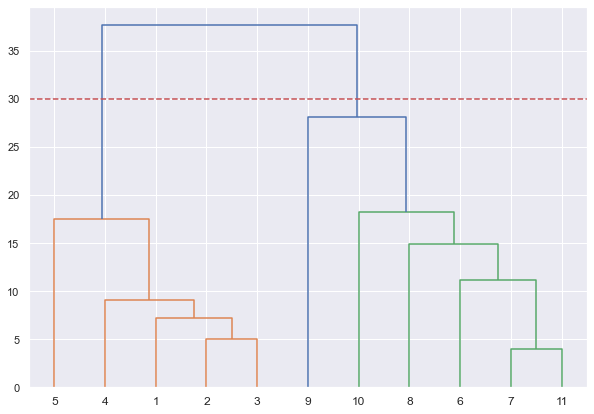

In [45]:
plt.figure(figsize=(10,7))
dendrogram(Z, labels=labels)
plt.axhline(y=30, color='r', linestyle='--')
plt.show()

## Scikit

In [48]:
from sklearn.cluster import AgglomerativeClustering

# model = AgglomerativeClustering(n_clusters=2)
model = AgglomerativeClustering(n_clusters=3)
# model = AgglomerativeClustering(n_clusters=None, distance_threshold=30)
model.fit_predict(arr)

array([1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 0], dtype=int64)

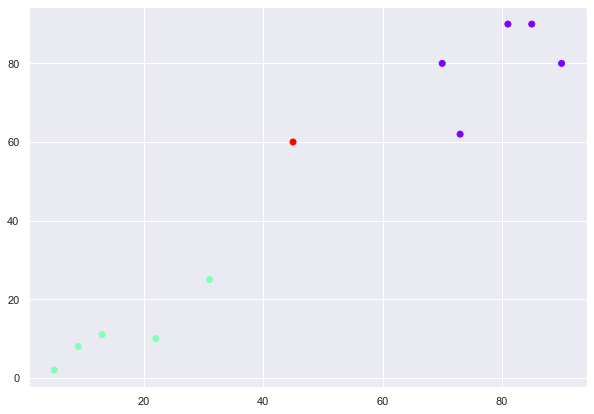

In [49]:
plt.figure(figsize=(10, 7))
plt.scatter(arr[:,0], arr[:,1], c=model.labels_, cmap='rainbow')

Al elegir 3 clusters vemos cómo el punto 9 tiene su propio cluster por estar más separado de los demás. Cuando elegimos 2 clusters el punto 9 pasa a formar parte del cluster de la derecha.

# Real dataset

In [68]:
df = pd.read_csv("../data/mall_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [69]:
df_mall = df.drop(['CustomerID', 'Gender'], axis=1)
df_mall

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


## Scipy

https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html

In [59]:
arr = np.array(df_mall)
Z = linkage(arr, method='ward')
Z

array([[ 65.        ,  68.        ,   1.        ,   2.        ],
       [129.        , 131.        ,   1.        ,   2.        ],
       [  3.        ,   5.        ,   1.73205081,   2.        ],
       [106.        , 109.        ,   2.        ,   2.        ],
       [ 48.        ,  49.        ,   2.        ,   2.        ],
       [ 92.        ,  96.        ,   2.23606798,   2.        ],
       [100.        , 105.        ,   2.23606798,   2.        ],
       [114.        , 115.        ,   2.23606798,   2.        ],
       [133.        , 137.        ,   2.44948974,   2.        ],
       [147.        , 159.        ,   2.44948974,   2.        ],
       [ 13.        ,  15.        ,   2.82842712,   2.        ],
       [ 83.        ,  85.        ,   2.82842712,   2.        ],
       [101.        , 205.        ,   2.88675135,   3.        ],
       [ 16.        ,  20.        ,   3.        ,   2.        ],
       [117.        , 119.        ,   3.        ,   2.        ],
       [156.        , 158

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [45.0, 45.0, 55.0, 55.0],
  [65.0, 65.0, 75.0, 75.0],
  [50.0, 50.0, 70.0, 70.0],
  [35.0, 35.0, 60.0, 60.0],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [85.0, 85.0, 102.5, 102.5],
  [47.5, 47.5, 93.75, 93.75],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [125.0, 125.0, 142.5, 142.5],
  [165.0, 165.0, 175.0, 175.0],
  [185.0, 185.0, 195.0, 195.0],
  [170.0, 170.0, 190.0, 190.0],
  [133.75, 133.75, 180.0, 180.0],
  [70.625, 70.625, 156.875, 156.875],
  [12.5, 12.5, 113.75, 113.75],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [235.0, 235.0, 245.0, 245.0],
  [265.0, 265.0, 275.0, 275.0],
  [255.0, 255.0, 270.0, 270.0],
  [240.0, 240.0, 262.5, 262.5],
  [212.5, 212.5, 251.25, 251.25],
  [295.0, 295.0, 305.0, 305.0],
  [285.0, 285.0, 300.0, 300.0],
  [315.0, 315.0, 325.0, 325.0],
  [345.0, 345.0, 355.0, 355.0],
  [335.0, 335.0, 350.0, 350.0],
  [320.0, 320.0, 342

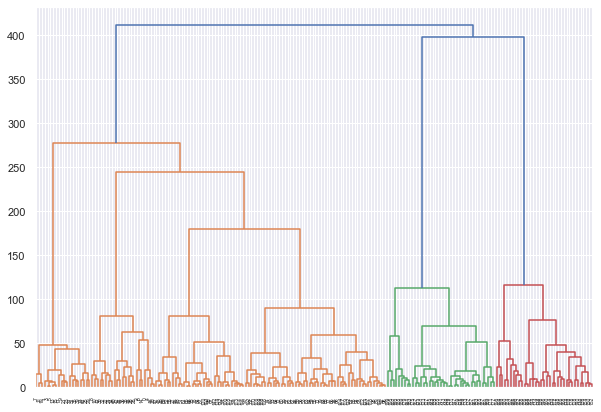

In [60]:
plt.figure(figsize=(10, 7))
dendrogram(Z)

## Scikit

In [61]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
predictions = model.fit_predict(arr)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2], dtype=int64)

In [62]:
arr

array([[ 19,  15,  39],
       [ 21,  15,  81],
       [ 20,  16,   6],
       [ 23,  16,  77],
       [ 31,  17,  40],
       [ 22,  17,  76],
       [ 35,  18,   6],
       [ 23,  18,  94],
       [ 64,  19,   3],
       [ 30,  19,  72],
       [ 67,  19,  14],
       [ 35,  19,  99],
       [ 58,  20,  15],
       [ 24,  20,  77],
       [ 37,  20,  13],
       [ 22,  20,  79],
       [ 35,  21,  35],
       [ 20,  21,  66],
       [ 52,  23,  29],
       [ 35,  23,  98],
       [ 35,  24,  35],
       [ 25,  24,  73],
       [ 46,  25,   5],
       [ 31,  25,  73],
       [ 54,  28,  14],
       [ 29,  28,  82],
       [ 45,  28,  32],
       [ 35,  28,  61],
       [ 40,  29,  31],
       [ 23,  29,  87],
       [ 60,  30,   4],
       [ 21,  30,  73],
       [ 53,  33,   4],
       [ 18,  33,  92],
       [ 49,  33,  14],
       [ 21,  33,  81],
       [ 42,  34,  17],
       [ 30,  34,  73],
       [ 36,  37,  26],
       [ 20,  37,  75],
       [ 65,  38,  35],
       [ 24,  38

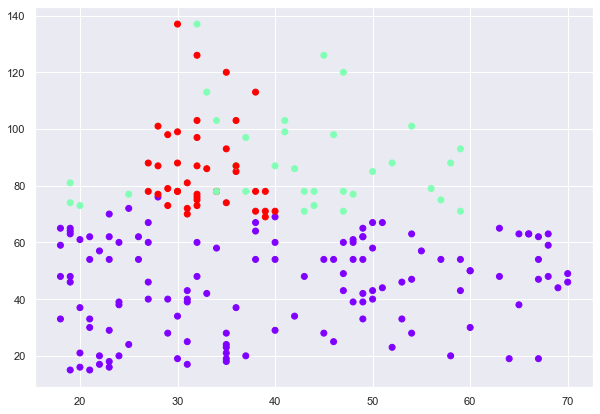

In [63]:
plt.figure(figsize=(10, 7))
plt.scatter(arr[:,0], arr[:,1], c=model.labels_, cmap='rainbow')

## Ajustar features

In [70]:
# Eliminamos la columna Age
df_mall = df.drop(['CustomerID', 'Gender', 'Age'], axis=1)
df_mall

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [35.0, 35.0, 45.0, 45.0],
  [20.0, 20.0, 40.0, 40.0],
  [5.0, 5.0, 30.0, 30.0],
  [55.0, 55.0, 65.0, 65.0],
  [85.0, 85.0, 95.0, 95.0],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [90.0, 90.0, 112.5, 112.5],
  [75.0, 75.0, 101.25, 101.25],
  [60.0, 60.0, 88.125, 88.125],
  [17.5, 17.5, 74.0625, 74.0625],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [165.0, 165.0, 175.0, 175.0],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [170.0, 170.0, 192.5, 192.5],
  [142.5, 142.5, 181.25, 181.25],
  [45.78125, 45.78125, 161.875, 161.875],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [222.5, 222.5, 252.5, 252.5],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [315.0, 315.0, 325.0, 325.0],
  [305.0, 305.0, 320.0, 320.0],
  [282.5, 282.5, 312.5, 312.5],
  [237.5, 237.5, 297.5, 297.5],
  [335.0, 33

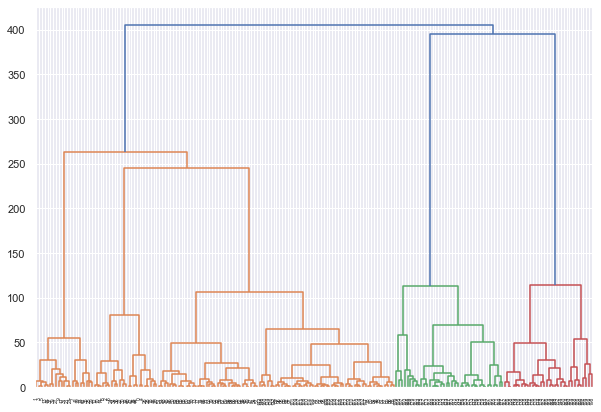

In [76]:
arr = np.array(df_mall)
Z = linkage(arr, method='ward')
Z
plt.figure(figsize=(10, 7))
dendrogram(Z)

In [77]:
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
predictions = model.fit_predict(arr)
predictions

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int64)

In [74]:
arr

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

Text(0, 0.5, 'Spending Score (1-100)')

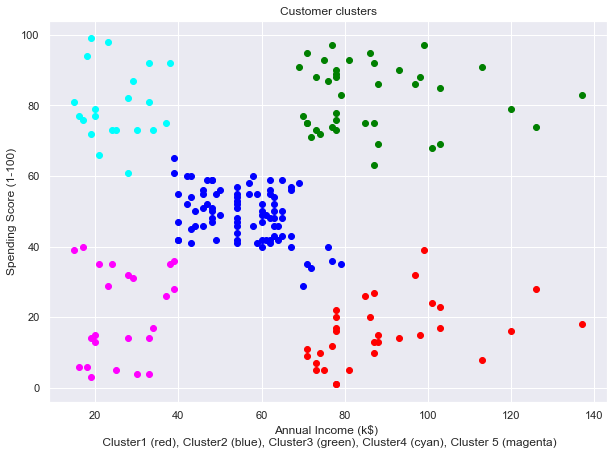

In [82]:
plt.figure(figsize=(10, 7))
plt.scatter(arr[predictions == 0, 0], arr[predictions == 0, 1], c='red', label='Cluster 1')
plt.scatter(arr[predictions == 1, 0], arr[predictions == 1, 1], c='blue', label='Cluster 2')
plt.scatter(arr[predictions == 2, 0], arr[predictions == 2, 1], c='green', label='Cluster 3')
plt.scatter(arr[predictions == 3, 0], arr[predictions == 3, 1], c='cyan', label='Cluster 4')
plt.scatter(arr[predictions == 4, 0], arr[predictions == 4, 1], c='magenta', label='Cluster 5')
plt.title("Customer clusters")
plt.xlabel("Annual Income (k$) \n Cluster1 (red), Cluster2 (blue), Cluster3 (green), Cluster4 (cyan), Cluster 5 (magenta)")
plt.ylabel("Spending Score (1-100)")

Cluster 1 (red): HIGH income vs. LOW spending
Cluster 2 (blue): NORMAL income vs. NORMAL spending
Cluster 3 (green): HIGH income vs. HIGH spending. TARGET.
Cluster 4 (cyan): LOW income vs. HIGH spending. (Aunque sea interesante puede ser problemático, por lo que podría ser descartable)
Cluster 5 (magenta): LOW income vs. LOW spending

Como campaña de marketing para un producto de high ticketing (> 1000 $) nuestro target podría ser el cluster 3.

In [88]:
df_mall['cluster'] = predictions + 1
df_mall['age'] = df['Age']
df_mall['gender'] = df['Gender']
df_mall

,Annual Income (k$),Spending Score (1-100),cluster,age,gender
0,15,39,5,19,Male
1,15,81,4,21,Male
2,16,6,5,20,Female
3,16,77,4,23,Female
4,17,40,5,31,Female
...,...,...,...,...,...
195,120,79,3,35,Female
196,126,28,1,45,Female
197,126,74,3,32,Male
198,137,18,1,32,Male


In [89]:
filter = df_mall['cluster'] == 3
df_cluster3 = df_mall[filter]
df_cluster3

,Annual Income (k$),Spending Score (1-100),cluster,age,gender
123,69,91,3,39,Male
125,70,77,3,31,Female
127,71,95,3,40,Male
129,71,75,3,38,Male
131,71,75,3,39,Male
133,72,71,3,31,Female
135,73,88,3,29,Female
137,73,73,3,32,Male
139,74,72,3,35,Female
141,75,93,3,32,Male


In [92]:
df_stats = df_cluster3.agg(['mean', 'median', 'std', 'min', 'max']).reset_index()
df_stats.drop(['cluster', 'gender'], axis=1)

,index,Annual Income (k$),Spending Score (1-100),age
0,mean,86.538462,82.128205,32.692308
1,median,79.000000,83.000000,32.000000
2,std,16.312485,9.364489,3.728650
3,min,69.000000,63.000000,27.000000
4,max,137.000000,97.000000,40.000000


In [94]:
df_cluster3['gender'].value_counts()

Female    21
Male      18
Name: gender, dtype: int64